## Monte Carlo Simulation of TSMC Stock price Using GBM

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
# 1. Load Data

ticker = "2330.TW"
company_name = "TSMC"
start_date = "2020-01-01"
end_date = "2026-05-01"

df = yf.download(ticker, start=start_date, end=end_date)

# Fix MultiIndex issue from yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Close"]].dropna().copy()

[*********************100%***********************]  1 of 1 completed


In [3]:
# 2. GBM Simulation Function

def run_gbm_simulation(
    prices,
    num_days,
    num_simulations=10_000,
    trading_days=252,
    random_seed=42
):

    log_returns = np.log(prices / prices.shift(1)).dropna()

    # Annualized drift and volatility
    mu = log_returns.mean() * trading_days
    sigma = log_returns.std() * np.sqrt(trading_days)

    S0 = float(prices.iloc[-1])
    dt = 1 / trading_days

    np.random.seed(random_seed)

    Z = np.random.normal(
        0,
        1,
        size=(num_days, num_simulations)
    )

    simulated_prices = np.zeros((num_days, num_simulations))
    simulated_prices[0] = S0

    for t in range(1, num_days):
        simulated_prices[t] = simulated_prices[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z[t]
        )

    return simulated_prices, mu, sigma, S0

In [4]:
# 3. Train-Test Split

split_date = "2024-01-01"

train_df = df[df.index < split_date].copy()
test_df = df[df.index >= split_date].copy()

num_days = len(test_df)
num_simulations = 10_000
random_seed = 42

In [5]:
# 4. Historical Simulation

simulated_prices, mu, sigma, S0 = run_gbm_simulation(
    prices=train_df["Close"],
    num_days=num_days,
    num_simulations=num_simulations,
    random_seed=random_seed
)

simulated_testing_df = pd.DataFrame(
    simulated_prices,
    index=test_df.index
)

median_path = simulated_testing_df.median(axis=1)
lower_band = simulated_testing_df.quantile(0.05, axis=1)
upper_band = simulated_testing_df.quantile(0.95, axis=1)

real_prices = test_df["Close"]

within_band = np.mean(
    (real_prices >= lower_band) &
    (real_prices <= upper_band)
)

actual_final_price = real_prices.iloc[-1]
simulated_median_final_price = median_path.iloc[-1]
simulated_lower_final_price = lower_band.iloc[-1]
simulated_upper_final_price = upper_band.iloc[-1]

print(f"Company: {company_name} ({ticker})")
print("=" * 60)
print(f"Training period: {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"Testing period: {test_df.index[0].date()} to {test_df.index[-1].date()}")
print("=" * 60)
print(f"Annualized drift (mu): {mu:.2%}")
print(f"Annualized volatility (sigma): {sigma:.2%}")
print("")
print(f"Actual final price: {actual_final_price:,.0f}")
print(f"Median simulated final price: {simulated_median_final_price:,.0f}")
print(f"5th percentile final price: {simulated_lower_final_price:,.0f}")
print(f"95th percentile final price: {simulated_upper_final_price:,.0f}")
print(f"Percentage within 5–95% band: {within_band:.2%}")

Company: TSMC (2330.TW)
Training period: 2020-01-02 to 2023-12-29
Testing period: 2024-01-02 to 2026-04-30
Annualized drift (mu): 16.78%
Annualized volatility (sigma): 27.39%

Actual final price: 2,135
Median simulated final price: 758
5th percentile final price: 391
95th percentile final price: 1,490
Percentage within 5–95% band: 33.63%


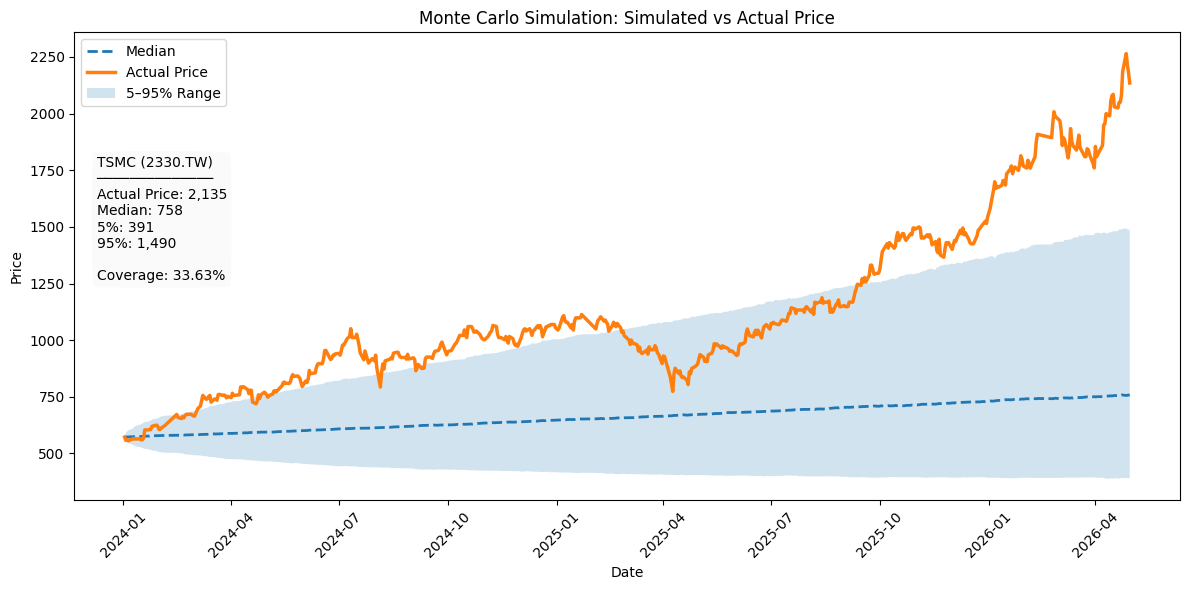

In [11]:
# 5. Plot Historical Performance Result

plt.figure(figsize=(12, 6))

plt.plot(
    test_df.index,
    median_path,
    linestyle="dashed",
    linewidth=2,
    label="Median"
)

plt.plot(
    test_df.index,
    real_prices,
    linewidth=2.5,
    label="Actual Price"
)

plt.fill_between(
    test_df.index,
    lower_band,
    upper_band,
    alpha=0.2,
    label="5–95% Range"
)

ax = plt.gca()

text_str = (
    f"{company_name} ({ticker})\n"
    "──────────────\n"
    f"Actual Price: {actual_final_price:,.0f}\n"
    f"Median: {simulated_median_final_price:,.0f}\n"
    f"5%: {simulated_lower_final_price:,.0f}\n"
    f"95%: {simulated_upper_final_price:,.0f}\n\n"
    f"Coverage: {within_band:.2%}"
)

ax.text(
    0.02, 0.6,
    text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round4,pad=0.4",
        facecolor="#f8f9fa",
        edgecolor="none",
        alpha=0.7
    )
)

plt.title("Monte Carlo Simulation: Simulated vs Actual Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# 6. Future Simulation

future_start = "2026-05-01"
future_days = 252
num_simulations = 10_000

future_simulated_prices, mu_future, sigma_future, S0_future = run_gbm_simulation(
    prices=df["Close"],
    num_days=future_days,
    num_simulations=num_simulations,
    random_seed=random_seed
)

future_dates = pd.bdate_range(
    start=future_start,
    periods=future_days
)

future_simulated_df = pd.DataFrame(
    future_simulated_prices,
    index=future_dates
)

future_median_path = future_simulated_df.median(axis=1)
future_lower_band = future_simulated_df.quantile(0.05, axis=1)
future_upper_band = future_simulated_df.quantile(0.95, axis=1)

final_prices = future_simulated_df.iloc[-1]

expected_price = final_prices.mean()
median_price = final_prices.median()
p5 = final_prices.quantile(0.05)
p95 = final_prices.quantile(0.95)

prob_up = np.mean(final_prices > S0_future)
prob_down_10 = np.mean(final_prices < S0_future * 0.9)
prob_up_20 = np.mean(final_prices > S0_future * 1.2)

print(f"Simulation starting price: {S0_future:,.0f}")
print(f"Annualized drift: {mu_future:.2%}")
print(f"Annualized volatility: {sigma_future:.2%}")
print("")
print(f"Expected price: {expected_price:,.0f}")
print(f"Median price: {median_price:,.0f}")
print(f"5th percentile: {p5:,.0f}")
print(f"95th percentile: {p95:,.0f}")
print("")
print(f"Probability price goes up: {prob_up:.2%}")
print(f"Probability of >10% drop: {prob_down_10:.2%}")
print(f"Probability of >20% gain: {prob_up_20:.2%}")

Simulation starting price: 2,135
Annualized drift: 32.34%
Annualized volatility: 29.90%

Expected price: 2,939
Median price: 2,808
5th percentile: 1,721
95th percentile: 4,583

Probability price goes up: 82.07%
Probability of >10% drop: 10.28%
Probability of >20% gain: 62.49%


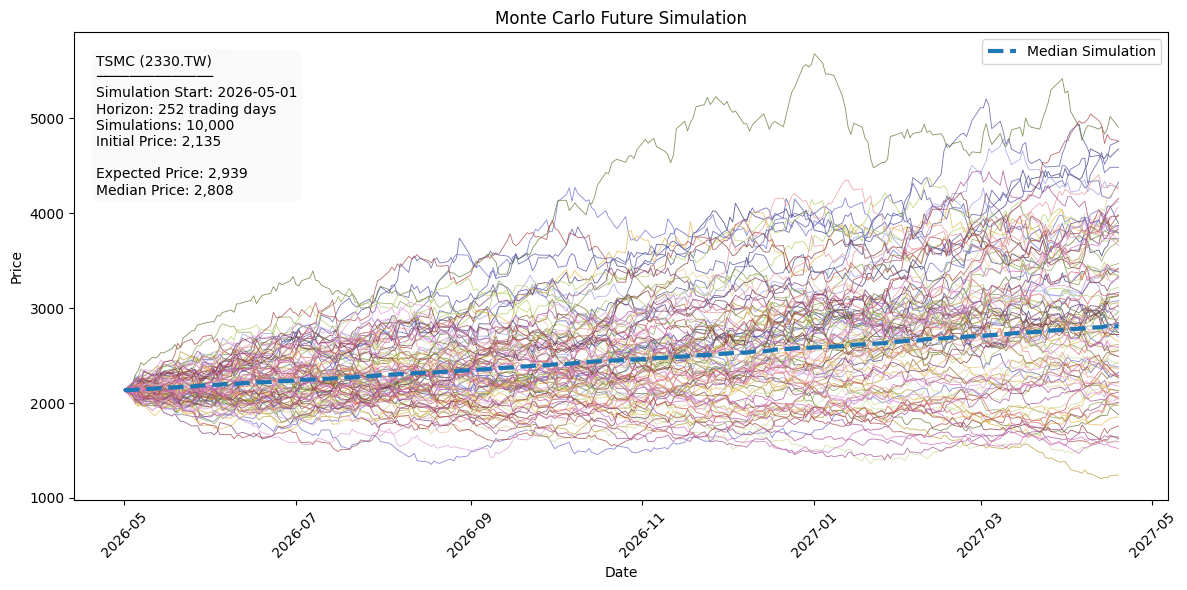

In [8]:
# 7. Plot Future Simulated Paths

num_paths_to_plot = 100
colors = cm.tab20b(np.linspace(0, 1, num_paths_to_plot))

plt.figure(figsize=(12, 6))

for i in range(num_paths_to_plot):
    plt.plot(
        future_simulated_df.index,
        future_simulated_df.iloc[:, i],
        alpha=0.8,
        linewidth=0.6,
        color=colors[i]
    )

plt.plot(
    future_simulated_df.index,
    future_median_path,
    linewidth=3,
    linestyle="dashed",
    label="Median Simulation"
)

ax = plt.gca()
text_str = (
    f"{company_name} ({ticker})\n"
    "──────────────\n"
    f"Simulation Start: {future_start}\n"
    f"Horizon: {future_days} trading days\n"
    f"Simulations: {num_simulations:,}\n"
    f"Initial Price: {S0_future:,.0f}\n\n"
    f"Expected Price: {expected_price:,.0f}\n"
    f"Median Price: {median_price:,.0f}"
)

ax.text(
    0.02, 0.8,
    text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round4,pad=0.4",
        facecolor="#f8f9fa",
        edgecolor="none",
        alpha=0.7
    )
)


plt.title("Monte Carlo Future Simulation")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

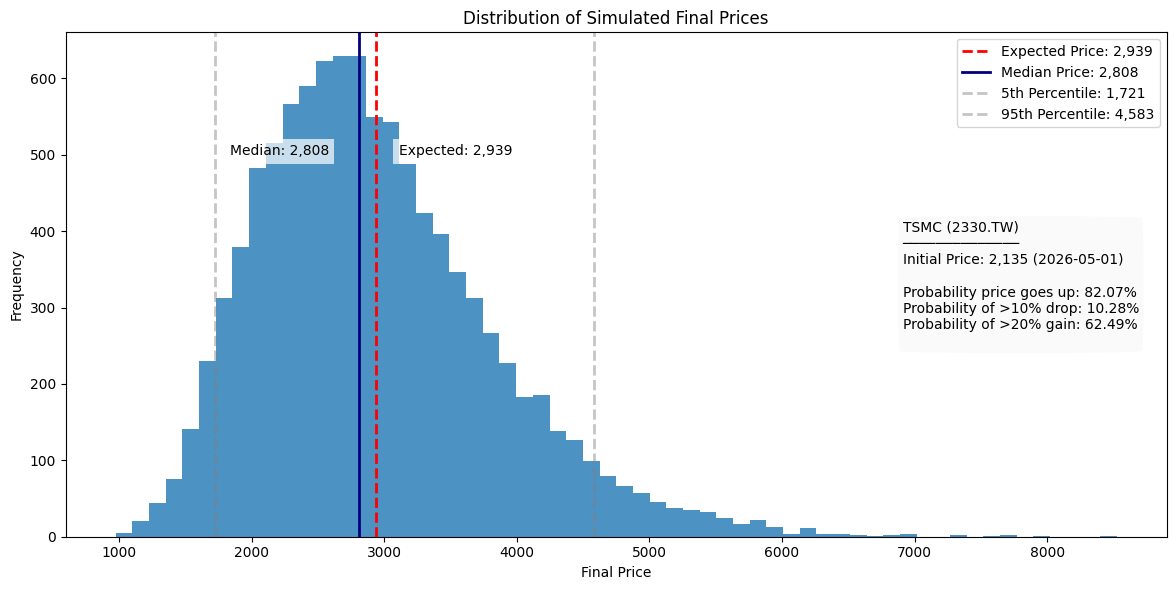

In [9]:
# 8. Plot Final Price Distribution

plt.figure(figsize=(12, 6))
plt.hist(final_prices, bins=60, alpha=0.8)

plt.axvline(expected_price, color="red", linewidth=2, linestyle="--", label=f"Expected Price: {expected_price:,.0f}")
plt.axvline(median_price, color="navy", linewidth=2, label=f"Median Price: {median_price:,.0f}")
plt.axvline(p5, color="gray", linewidth=2, linestyle="--", label=f"5th Percentile: {p5:,.0f}", alpha=0.45)
plt.axvline(p95, color="gray", linewidth=2, linestyle="--", label=f"95th Percentile: {p95:,.0f}", alpha=0.45)

y_position = plt.gca().get_ylim()[1] * 0.75

plt.text(
    expected_price + 600,
    y_position,
    f"Expected: {expected_price:,.0f}",
    ha="center",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

plt.text(
    median_price - 600,
    y_position,
    f"Median: {median_price:,.0f}",
    ha="center",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)


ax = plt.gca()
text_str = (
    f"{company_name} ({ticker})\n"
    "──────────────\n"
    f"Initial Price: {S0_future:,.0f} ({future_start})\n\n"
    f"Probability price goes up: {prob_up:.2%}\n"
    f"Probability of >10% drop: {prob_down_10:.2%}\n"
    f"Probability of >20% gain: {prob_up_20:.2%}\n"
)

ax.text(
    0.76, 0.5,
    text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round4,pad=0.4",
        facecolor="#f8f9fa",
        edgecolor="none",
        alpha=0.7
    )
)


plt.title("Distribution of Simulated Final Prices")
plt.xlabel("Final Price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()